In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve)

# Load clean data
df = pd.read_csv("../data/myopia_model_ready.csv")

# Define features and target
X = df.drop('MYOPIC', axis=1)
y = df['MYOPIC']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("DATASET:")
print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set:  {X_test.shape[0]} patients")
print(f"Myopic in training: {y_train.sum()}")
print(f"Myopic in testing:  {y_test.sum()}")

# Scale data — KNN requires this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nData scaled successfully!")

# Find optimal K using square root rule
import math
optimal_k = math.sqrt(len(X_train))
print(f"\nOptimal K (square root rule): {optimal_k:.1f}")
print(f"Rounding to nearest odd number: {int(optimal_k)//2*2+1}")

DATASET:
Training set: 494 patients
Testing set:  124 patients
Myopic in training: 65
Myopic in testing:  16

Data scaled successfully!

Optimal K (square root rule): 22.2
Rounding to nearest odd number: 23


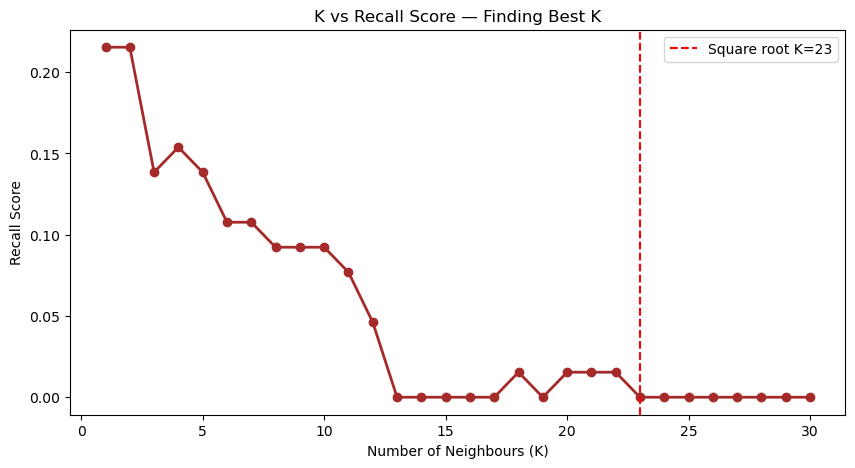

Best K by recall: 1
Best recall score: 0.2154

KNN trained successfully with K=1!


In [2]:
# ============================================
# FIND BEST K USING CROSS VALIDATION
# ============================================
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
recall_scores = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance'
    )
    scores = cross_val_score(knn, X_train_scaled, y_train,
                             cv=5, scoring='recall')
    recall_scores.append(scores.mean())

# Plot K vs Recall
plt.figure(figsize=(10, 5))
plt.plot(k_values, recall_scores,
         marker='o', color='brown', linewidth=2)
plt.axvline(x=23, color='red', linestyle='--',
            label='Square root K=23')
plt.title("K vs Recall Score — Finding Best K")
plt.xlabel("Number of Neighbours (K)")
plt.ylabel("Recall Score")
plt.legend()
plt.show()

best_k = k_values[recall_scores.index(max(recall_scores))]
print(f"Best K by recall: {best_k}")
print(f"Best recall score: {max(recall_scores):.4f}")

# ============================================
# TRAIN KNN WITH BEST K
# ============================================
model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance'
)
model.fit(X_train_scaled, y_train)
print(f"\nKNN trained successfully with K={best_k}!")

KNN RESULTS (K=1):
Accuracy:  0.8226
ROC AUC:   0.5787

Classification Report:
              precision    recall  f1-score   support

  Not Myopic       0.89      0.91      0.90       108
      Myopic       0.29      0.25      0.27        16

    accuracy                           0.82       124
   macro avg       0.59      0.58      0.58       124
weighted avg       0.81      0.82      0.82       124



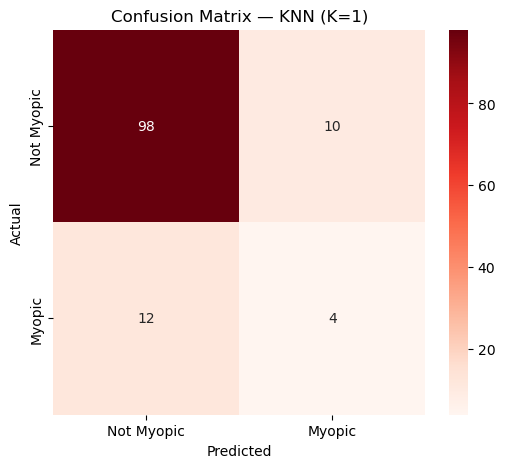

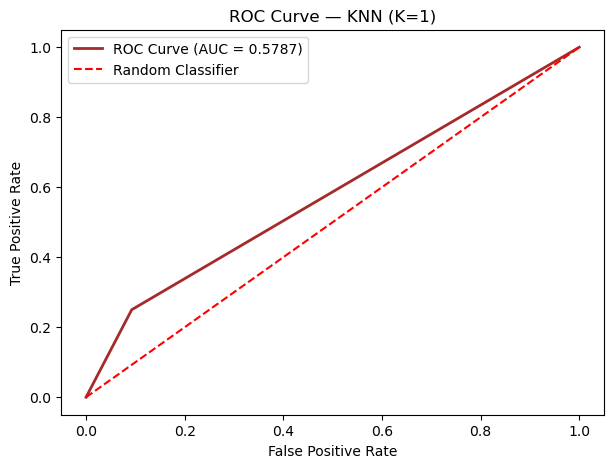


Results saved:
{'Model': 'KNN (K=1)', 'Accuracy': 0.8226, 'ROC_AUC': 0.5787}


In [3]:
# ============================================
# MAKE PREDICTIONS
# ============================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ============================================
# EVALUATION METRICS
# ============================================
print("KNN RESULTS (K=1):")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Myopic', 'Myopic']))

# ============================================
# CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Myopic', 'Myopic'],
            yticklabels=['Not Myopic', 'Myopic'])
plt.title("Confusion Matrix — KNN (K=1)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================
# ROC CURVE
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='brown',
         linewidth=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red',
         linestyle='--', label='Random Classifier')
plt.title("ROC Curve — KNN (K=1)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Save results
knn_results = {
    'Model': 'KNN (K=1)',
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_prob), 4)
}
print("\nResults saved:")
print(knn_results)